# Final Project: Predicting Tumor Status 

By Kavan Wills, Magnus Lie, & Isra Abudiab

Dataset: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

# Question

Using breast cancer data, can we predict whether a tumor is malignant or benign? Benign tumors are non-cancerous, slow-growing, encapsulated masses that do not spread to other body parts. Malignant tumors are cancerous, fast-growing, and invade nearby tissues or metastasize to distant organs. So, identifying which is which is important for the patient's health! In this project, we will use logistic regression, decision trees, and finally random forest classifiers for prediction. We will begin with exploratory data analysis, then move to modelling, and finally to our conclusions. Let's get started!

# Exploratory Data Analysis

The dataset contains 569 tumor samples. Each sample is labeled as either benign (B) or malignant (M). After dropping the ID column and the empty Unnamed: 32 column, the dataset contains 30 numeric predictor variables. These variables measure properties of cell nuclei, including radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, and fractal dimension. The dataset is mostly clean, so the main goal of EDA is to understand which features appear to separate benign and malignant tumors.

In [24]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix, precision_recall_curve, accuracy_score, recall_score, precision_score
from sklearn.model_selection import GridSearchCV

In [25]:
df = pd.read_csv("Cancer.csv")

In [26]:
df = df.drop(columns=["id", "Unnamed: 32"])

In [27]:
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [29]:
df["diagnosis"].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

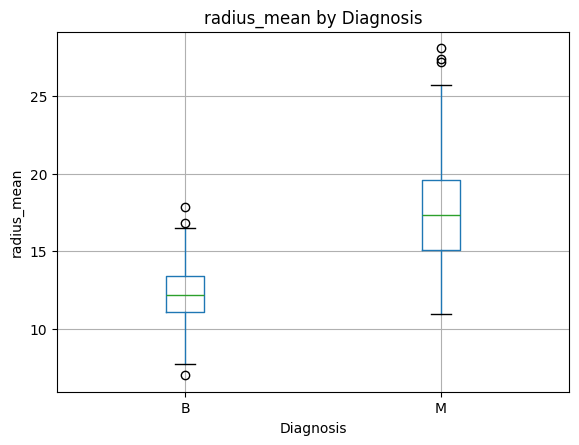

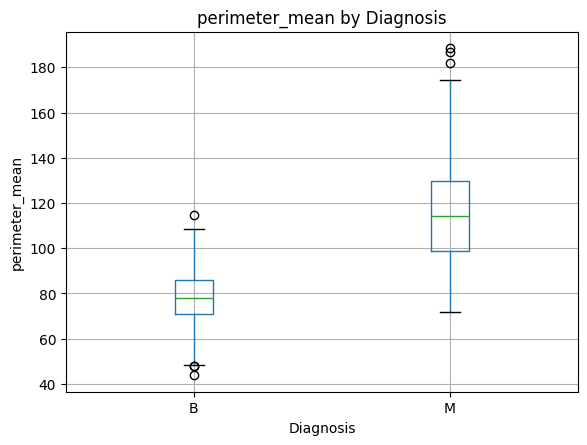

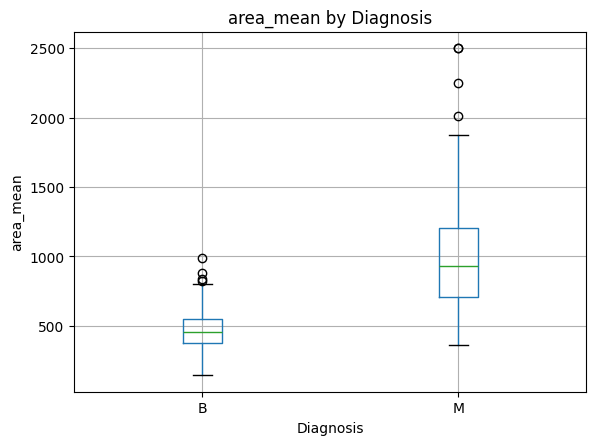

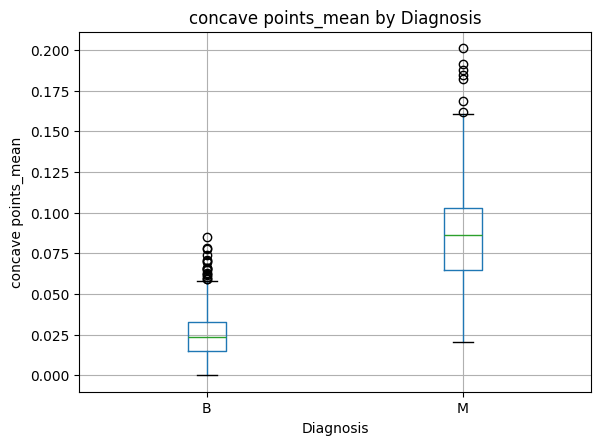

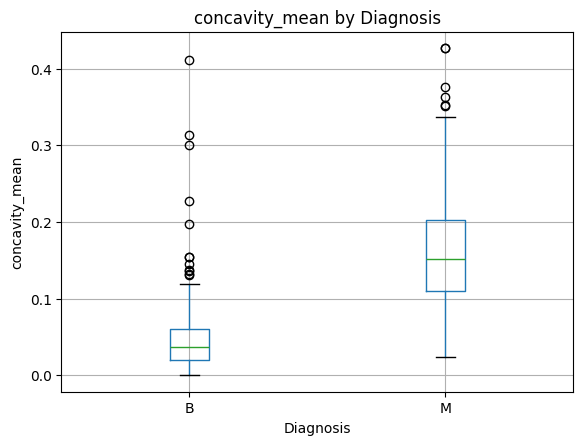

In [30]:
important_features = [
    "radius_mean",
    "perimeter_mean",
    "area_mean",
    "concave points_mean",
    "concavity_mean"
]

for feature in important_features:
    df.boxplot(column=feature, by="diagnosis")
    plt.title(f"{feature} by Diagnosis")
    plt.suptitle("")
    plt.xlabel("Diagnosis")
    plt.ylabel(feature)
    plt.show()

The class balance count shows that the dataset contains more benign tumors than malignant tumors, but both classes have enough examples for classification. This matters because model evaluation should not rely only on accuracy; we also need to pay attention to how well the model identifies malignant tumors.

The boxplots suggest that malignant tumors tend to have higher values for radius, perimeter, area, concave points, and concavity. These features are related to tumor size and irregularity, so the separation between benign and malignant cases makes sense for this prediction task. Although there is still some overlap between the two groups, the median values for malignant tumors are consistently higher across these features. This gives us a reason to believe that classification models such as logistic regression, decision trees, and random forests may be able to predict diagnosis from the numeric measurements.

In [31]:
# Implementing cross-validation to test whether sqrt or log1p transformation has a better baseline accuracy
from sklearn.model_selection import cross_val_score

skewed_features = [
    "concavity_mean", "concave points_mean", "radius_se", "perimeter_se",
    "area_se", "smoothness_se", "concavity_se", "concave points_se",
    "fractal_dimension_se", "area_worst"
]

# Temporary X and y
X_temp = df.drop(columns=["diagnosis"])
y_temp = df["diagnosis"]
baseline_pipe = Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(solver="lbfgs", max_iter=1000))])

# Sqrt
X_sqrt = X_temp.copy()
X_sqrt[skewed_features] = np.sqrt(X_sqrt[skewed_features])
sqrt_score = cross_val_score(baseline_pipe, X_sqrt, y_temp, cv=5).mean()

# Log1p
X_log = X_temp.copy()
X_log[skewed_features] = np.log1p(X_log[skewed_features])
log_score = cross_val_score(baseline_pipe, X_log, y_temp, cv=5).mean()

print(f"Sqrt Transformed Accuracy: {sqrt_score:.4f}")
print(f"Log Transformed Accuracy: {log_score:.4f}")

# Apply whichever is the best
if log_score > sqrt_score:
    df[skewed_features] = np.log1p(df[skewed_features])
else:
    df[skewed_features] = np.sqrt(df[skewed_features])

Sqrt Transformed Accuracy: 0.9772
Log Transformed Accuracy: 0.9772


In [32]:
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

# Methods

We tested three classification models: logistic regression, decision tree, and random forest. Logistic regression was used as a simple baseline classifier. The decision tree was used because it creates interpretable decision rules. The random forest was used because it combines many decision trees and can often improve performance by reducing overfitting.

All models were created using sklearn pipelines. We used an 80/20 train-test split with a fixed random state and stratification by diagnosis so that the benign/malignant class balance would be similar in both the training and testing sets.

In [33]:
log_reg_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer(
        transformers=[("numeric", StandardScaler(), X.columns)],
        remainder='passthrough')),
    ('classifier', LogisticRegression(random_state=42, solver="lbfgs"))
])

In [34]:
dt_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer(
        transformers=[("numeric", StandardScaler(), X.columns)],
        remainder='passthrough')),
    ('classifier', DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_leaf=5))
])

In [35]:
random_forest_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer(
        transformers=[("numeric", StandardScaler(), X.columns)],
        remainder='passthrough')),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=200,
    #max_depth=5,
    #min_samples_leaf=5,
    bootstrap=True, 
    oob_score=True,
    #class_weight=True
    ))
])

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# Hyperparameter Tuning for Logistic Regression
param_grid_lr = {
    'classifier__C': [0.1, 1.0, 10.0, 100.0],
    'classifier__max_iter': [1000, 2000]
}

grid_search_lr = GridSearchCV(log_reg_pipeline, param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_lr.fit(X_train, y_train)

print("Best Logistic Regression Parameters:", grid_search_lr.best_params_)

# Get best estimator
logReg = grid_search_lr.best_estimator_

logReg_preds = logReg.predict(X_test)
logReg_preds_odds = logReg.predict_proba(X_test)

Best Logistic Regression Parameters: {'classifier__C': 1.0, 'classifier__max_iter': 1000}


In [ ]:
# Hyperparameter Tuning for Decision Tree
param_grid_dt = {
    'classifier__max_depth': [None, 5, 10, 15],
    'classifier__min_samples_leaf': [1, 2, 5, 10],
    'classifier__criterion': ['gini', 'entropy']
}

grid_search_dt = GridSearchCV(dt_pipeline, param_grid_dt, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_dt.fit(X_train, y_train)

print("Best Decision Tree Parameters:", grid_search_dt.best_params_)

# Get best estimator
dt = grid_search_dt.best_estimator_

dt_preds = dt.predict(X_test)
dt_preds_odds = dt.predict_proba(X_test)

In [39]:
rf = random_forest_pipeline.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_preds_odds = rf.predict_proba(X_test)

# Evaluation

For model evaluation, we focused on more than just overall accuracy. Because this project predicts whether a tumor is benign or malignant, the most concerning mistake is a false negative: predicting that a malignant tumor is benign. For that reason, recall for the malignant class is especially important. We also used confusion matrices to see the actual types of errors each model made, false positive rate to measure how often benign tumors were incorrectly classified as malignant, and ROC/AUC and precision-recall curves to compare model performance across different thresholds. This gives a more complete picture of each model than accuracy alone.

In [40]:
# Confusion matrix for Logistic Regression
cm = confusion_matrix(y_test, logReg_preds, labels=["M","B"])
cm_logReg = pd.DataFrame(cm, index=["M","B"], columns=["M","B"])

print(f"Logistic Regression Confusion Matrix(Actual=Vertical, Predicted=Horizontal)\n{cm_logReg}")

# Confusion matrix for Decision Tree
cm = confusion_matrix(y_test, dt_preds, labels=["M","B"])
cm_decisionTree = pd.DataFrame(cm, index=["M","B"], columns=["M","B"])

print(f"Decision Tree Confusion Matrix(Actual=Vertical, Predicted=Horizontal)\n{cm_decisionTree}")

# Confusion matrix for Random Forest
cm = confusion_matrix(y_test, rf_preds, labels=["M", "B"])
cm_randomForest = pd.DataFrame(cm, index=["M", "B"], columns=["M", "B"])

print(f"Random Forest Confusion Matrix(Actual=Vertical, Predicted=Horizontal)\n{cm_randomForest}")

Logistic Regression Confusion Matrix(Actual=Vertical, Predicted=Horizontal)
    M   B
M  41   1
B   1  71
Decision Tree Confusion Matrix(Actual=Vertical, Predicted=Horizontal)
    M   B
M  34   8
B   3  69
Random Forest Confusion Matrix(Actual=Vertical, Predicted=Horizontal)
    M   B
M  38   4
B   0  72


In [41]:
# TPR AND FPR for Logistic Regression
TPR_log = cm_logReg.loc["M", "M"] / cm_logReg.loc["M"].sum()
FPR_log = cm_logReg.loc["B", "M"] / cm_logReg.loc["B"].sum()

print(f"Logistic Regression\nTPR : {TPR_log}\nFPR : {FPR_log}")

# TPR AND FPR for Decision Tree
TPR_dt = cm_decisionTree.loc["M", "M"] / cm_decisionTree.loc["M"].sum()
FPR_dt = cm_decisionTree.loc["B", "M"] / cm_decisionTree.loc["B"].sum()

print(f"Decision Tree\nTPR : {TPR_dt}\nFPR : {FPR_dt}")

# TPR AND FPR for Random Forest
TPR_rf = cm_randomForest.loc["M", "M"] / cm_randomForest.loc["M"].sum()
FPR_rf = cm_randomForest.loc["B", "M"] / cm_randomForest.loc["B"].sum()

print(f"Random Forest\nTPR : {TPR_rf}\nFPR : {FPR_rf}")

Logistic Regression
TPR : 0.9761904761904762
FPR : 0.013888888888888888
Decision Tree
TPR : 0.8095238095238095
FPR : 0.041666666666666664
Random Forest
TPR : 0.9047619047619048
FPR : 0.0


In [42]:
print("Logistic Regression:")
print(classification_report(y_test, logReg_preds))

print("Decision Tree:")
print(classification_report(y_test, dt_preds))

print("Random Forest:")
print(classification_report(y_test, rf_preds))

Logistic Regression:
              precision    recall  f1-score   support

           B       0.99      0.99      0.99        72
           M       0.98      0.98      0.98        42

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Decision Tree:
              precision    recall  f1-score   support

           B       0.90      0.96      0.93        72
           M       0.92      0.81      0.86        42

    accuracy                           0.90       114
   macro avg       0.91      0.88      0.89       114
weighted avg       0.90      0.90      0.90       114

Random Forest:
              precision    recall  f1-score   support

           B       0.95      1.00      0.97        72
           M       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97

Logistic Regression AUC: 0.996031746031746


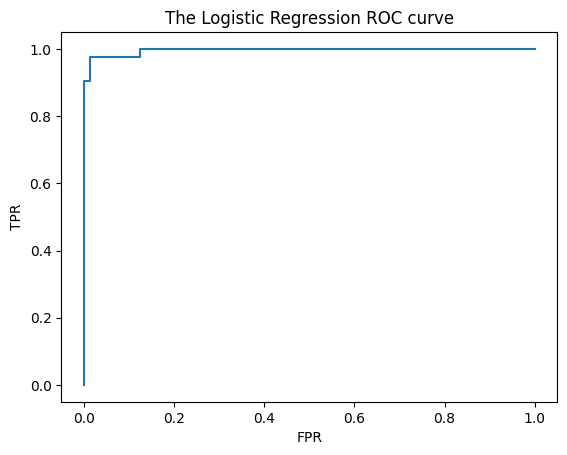

Decision Tree AUC: 0.9715608465608466


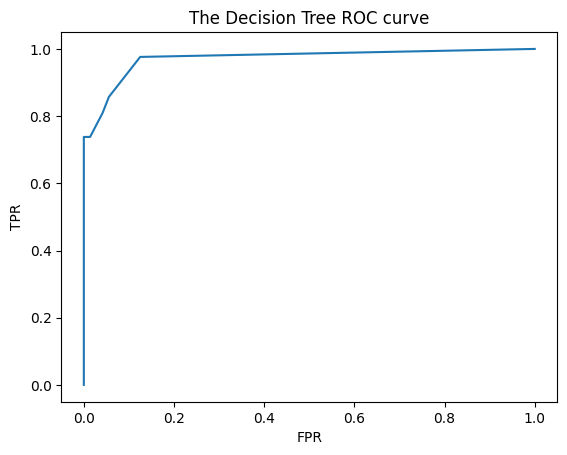

Random Forest AUC: 0.9940476190476191


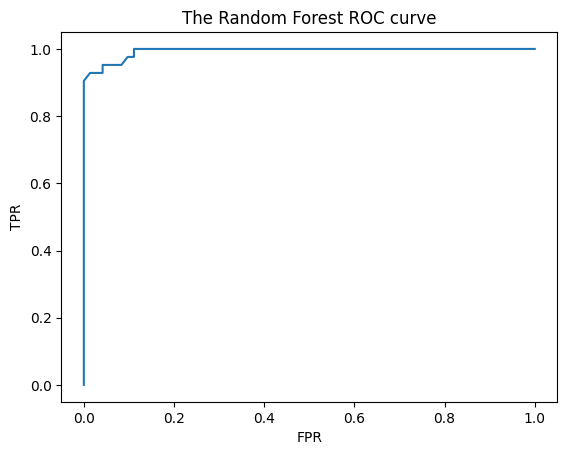

In [43]:
# Define the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, logReg_preds_odds[:,1], pos_label="M")
# Grab the AUC
roc_auc = auc(fpr, tpr)
print(f"Logistic Regression AUC: {roc_auc}")

# Plot the ROC Graph to see visually how it looks
plt.plot(fpr, tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("The Logistic Regression ROC curve")
plt.show()

# Define the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, dt_preds_odds[:,1], pos_label="M")
# Grab the AUC
roc_auc = auc(fpr, tpr)
print(f"Decision Tree AUC: {roc_auc}")

# Plot the ROC Graph to see visually how it looks
plt.plot(fpr, tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("The Decision Tree ROC curve")
plt.show()

# Define the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, rf_preds_odds[:, 1], pos_label="M")
# Grab the AUC
roc_auc = auc(fpr, tpr)
print(f"Random Forest AUC: {roc_auc}")

# Plot the ROC Graph to see visually how it looks
plt.plot(fpr, tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("The Random Forest ROC curve")
plt.show()


Logistic Regression Precision-Recall AUC: 0.9939916473155868
Decision Tree Precision-Recall AUC: 0.9653484005622164
Random Forest Precision-Recall AUC: 0.9908841733886486


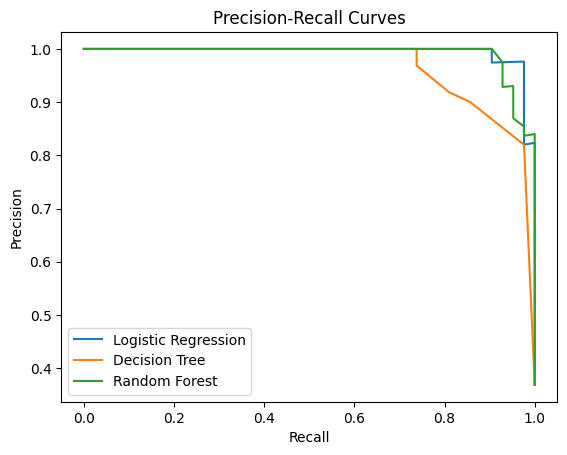

In [44]:
# Precision-recall curves for all three models.
# We use "M" as the positive class because identifying malignant tumors is the main concern.

# Logistic Regression
precision_log, recall_log, thresholds_log = precision_recall_curve(
    y_test,
    logReg_preds_odds[:, 1],
    pos_label="M"
)

pr_auc_log = auc(recall_log, precision_log)
print(f"Logistic Regression Precision-Recall AUC: {pr_auc_log}")


# Decision Tree
precision_dt, recall_dt, thresholds_dt = precision_recall_curve(
    y_test,
    dt_preds_odds[:, 1],
    pos_label="M"
)

pr_auc_dt = auc(recall_dt, precision_dt)
print(f"Decision Tree Precision-Recall AUC: {pr_auc_dt}")


# Random Forest
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(
    y_test,
    rf_preds_odds[:, 1],
    pos_label="M"
)

pr_auc_rf = auc(recall_rf, precision_rf)
print(f"Random Forest Precision-Recall AUC: {pr_auc_rf}")


# Plot all precision-recall curves together
plt.plot(recall_log, precision_log, label="Logistic Regression")
plt.plot(recall_dt, precision_dt, label="Decision Tree")
plt.plot(recall_rf, precision_rf, label="Random Forest")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.show()

In [45]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, logReg_preds),
        accuracy_score(y_test, dt_preds),
        accuracy_score(y_test, rf_preds)
    ],
    "Recall for Malignant": [
        recall_score(y_test, logReg_preds, pos_label="M"),
        recall_score(y_test, dt_preds, pos_label="M"),
        recall_score(y_test, rf_preds, pos_label="M")
    ],
    "Precision for Malignant": [
        precision_score(y_test, logReg_preds, pos_label="M"),
        precision_score(y_test, dt_preds, pos_label="M"),
        precision_score(y_test, rf_preds, pos_label="M")
    ],
    "False Positive Rate": [
        FPR_log,
        FPR_dt,
        FPR_rf
    ],
    "Precision-Recall AUC": [
        pr_auc_log,
        pr_auc_dt,
        pr_auc_rf
    ]
})

comparison

,Model,Accuracy,Recall for Malignant,Precision for Malignant,False Positive Rate,Precision-Recall AUC
0,Logistic Regression,0.982456,0.976190,0.976190,0.013889,0.993992
1,Decision Tree,0.903509,0.809524,0.918919,0.041667,0.965348
2,Random Forest,0.964912,0.904762,1.000000,0.000000,0.990884


# Conclusions

Our results show that classification models can predict whether a tumor is benign or malignant using cell-nucleus measurements with strong accuracy. The EDA supported this because the boxplots showed clear differences between benign and malignant tumors for features such as radius, perimeter, area, concavity, and concave points. Malignant tumors generally had higher values for these size and irregularity measurements, which gave us a reason to expect the models to separate the two classes well.

Overall, logistic regression performed best in this version of the project. It had the highest accuracy at about 98.2%, the strongest malignant recall at about 97.6%, and the highest ROC/AUC and precision-recall AUC. This is important because recall for malignant tumors matters most in this problem: a false negative would mean predicting that a malignant tumor is benign. The random forest also performed well, with about 96.5% accuracy and a very low false positive rate, but it missed more malignant tumors than logistic regression. The decision tree was easier to interpret, but it had the weakest performance overall, especially for malignant recall.

There are limitations to this project. The dataset is relatively small and already cleaned, so it does not fully represent messy real-world medical data. It also does not include broader patient information such as age, symptoms, medical history, imaging context, or doctor judgment. Because of this, the model should not be treated as a replacement for medical diagnosis. Instead, this project shows how data science methods can support classification using structured medical measurements.

# Team Contribution